# Phase 2: SOARM Integration Check (Colab verification)

Re-prove every Phase 2 requirement on the Colab GPU runtime where Phase 3 will run
(D-10). All values below are the finalized outputs of plans 02-01..02-04 — local
`soarm_sanity.py --check all` is 6/6 GREEN; this notebook is the Colab half.

## Requirements

- [ ] ENV-04: SOARM MJCF (arm + gripper) compiles under MuJoCo; `MountedSoarm101` registered
- [ ] ENV-05: robosuite name mapping resolves; `OffScreenRenderEnv(robots=["Soarm101"])` instantiates
- [ ] SC-1: peak contact force < 10 N at reset after settling (local baseline 0.024 N)
- [ ] ENV-07: agentview + eye_in_hand frames render, right-side-up, visually correct (human judgment)
- [ ] ENV-06: 3 finalized libero_spatial tasks each run 50 random-action steps without crashing

## Usage

**BLOCK A** (install): Run all BLOCK A cells top to bottom on a **GPU runtime**
(T4 is sufficient — no VLA model loads here), then **Runtime → Restart runtime**.

**BLOCK B** (verification): After restart, **re-run Cell 1 (path configuration)**,
then run the BLOCK B cells top to bottom.

> Environment contract: this notebook reuses Phase 1's proven install/bootstrap
> sequence verbatim (see `.planning/phases/01-colab-environment-setup/01-DEBUG-HISTORY.md`).
> Do not reorder or skip cells.


In [ ]:
# Clone/pull the private SoARM-Research repo from GitHub. Uses getpass()
# instead of Colab Secrets — the VS Code Colab extension has no Secrets
# key-icon UI, and getpass() never writes the token into this notebook's
# saved source (unlike a literal hardcoded value, which would leak into git
# history permanently the moment this notebook is committed).
#
# One-time setup: create a GitHub Personal Access Token (Settings > Developer
# settings > Personal access tokens > Fine-grained, scoped to this repo,
# Contents: Read-only). You'll be prompted for it below ONLY on a fresh
# clone (first run of a new Colab VM) — after that, the token is cached in
# this VM's local .git/config for subsequent `git pull`s, and is never
# written anywhere that syncs back to git.
import os
import subprocess
import getpass

REPO_ROOT = "/content/SoARM-Research"

if not os.path.exists(REPO_ROOT):
    GITHUB_TOKEN = getpass.getpass("GitHub token (fine-grained PAT, read-only, scoped to vansh-fyi/SO-ARM-research): ")
    _authed_url = f"https://{GITHUB_TOKEN}@github.com/vansh-fyi/SO-ARM-research.git"
    print(f"Cloning SoARM-Research -> {REPO_ROOT} ...")
    _r = subprocess.run(["git", "clone", "--depth", "1", _authed_url, REPO_ROOT], capture_output=True, text=True)
    del GITHUB_TOKEN, _authed_url  # never keep the token in a live notebook variable longer than needed
else:
    print(f"{REPO_ROOT} already exists — pulling latest ...")
    _r = subprocess.run(["git", "pull"], cwd=REPO_ROOT, capture_output=True, text=True)

if _r.returncode != 0:
    raise RuntimeError(
        "git clone/pull failed — check the token is valid and has read access to "
        "vansh-fyi/SO-ARM-research (the raw git error is withheld here so a bad "
        "token never leaks into cell output)"
    )

_sha = subprocess.run(["git", "rev-parse", "--short", "HEAD"], cwd=REPO_ROOT, capture_output=True, text=True).stdout.strip()
print(f"SoARM-Research resolved commit: {_sha}")

In [ ]:
import os

# ── USER CONFIGURATION ──────────────────────────────────────────────────────
# Set REPO_ROOT to the path where the SoARM-Research repo lives on Colab.
# NOTE: this notebook requires the repo's OWN LIBERO fork (SOARM assets and
# classes added in plans 02-01..02-04) — upstream LIBERO will NOT work.
REPO_ROOT = "/content/SoARM-Research"
# ────────────────────────────────────────────────────────────────────────────

# Derived path constants (do not edit these)
LIBERO_PKG  = f"{REPO_ROOT}/LIBERO"                 # path to setup.py directory
LIBERO_ROOT = f"{REPO_ROOT}/LIBERO/libero/libero"
OUT_DIR     = f"{REPO_ROOT}/LIBERO/notebooks/outputs"

# SOARM assets under test (added in plans 02-01/02-02, tuned in 02-03/02-04)
ARM_XML     = f"{LIBERO_ROOT}/assets/robots/soarm101/robot.xml"
GRIPPER_XML = f"{LIBERO_ROOT}/assets/grippers/soarm_gripper.xml"
BDDL_DIR    = f"{LIBERO_ROOT}/bddl_files/libero_spatial"

# Final libero_spatial tasks (D-03 resolved in plan 02-04) — hardcoded verbatim
# from explorations/soarm_sanity.py TASKS. ENV-05/SC-1/ENV-07 use TASKS[0];
# ENV-06 loops over all three.
TASKS = [
    "pick_up_the_black_bowl_from_table_center_and_place_it_on_the_plate.bddl",
    "pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate.bddl",
    "pick_up_the_black_bowl_on_the_ramekin_and_place_it_on_the_plate.bddl",
]

# Create outputs directory so Block B render cells can save there
os.makedirs(OUT_DIR, exist_ok=True)

print(f"REPO_ROOT   = {REPO_ROOT}")
print(f"LIBERO_PKG  = {LIBERO_PKG}")
print(f"LIBERO_ROOT = {LIBERO_ROOT}")
print(f"OUT_DIR     = {OUT_DIR}")
print(f"BDDL_DIR    = {BDDL_DIR}")
print(f"TASKS       = {len(TASKS)} libero_spatial tasks (D-03 final)")
print(f"Saved → {OUT_DIR}  (outputs directory ready)")


In [3]:
# GPU assertion — this notebook loads NO VLA model, so a T4 is sufficient
# (D-10: only env creation, physics stepping, and EGL rendering run here;
# model-load checks stay in the Phase 1 / Phase 3 notebooks).
import torch

assert torch.cuda.is_available(), (
    "No GPU available. Go to Runtime > Change runtime type > Hardware accelerator > GPU."
)

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"GPU:  {gpu_name}")
print(f"VRAM: {vram_gb:.1f} GB")
print("GPU OK — T4 or better is sufficient for this notebook (no model loads).")


GPU:  Tesla T4
VRAM: 15.6 GB
GPU OK — T4 or better is sufficient for this notebook (no model loads).


---

## BLOCK A: Install

Run all cells in this block **top to bottom**, then restart the runtime.

**Ordering is critical** — do not reorder or skip cells:

1. EGL system packages (apt) must install before pip mujoco
2. PyTorch must install before flash-attn (flash-attn compiles against torch CUDA headers)
3. The custom transformers fork must install last (prevents pip downgrade to PyPI version)
4. The numpy ABI gate cell must run last — after all other installs (Steps 1-6) — and must print PASS before you restart the runtime

---

In [4]:
# Step 1 of 6 — EGL system packages
# Must run BEFORE pip mujoco install.
# These C libraries must exist when the mujoco Python extension builds.
# apt-get update refreshes repo index — prevents 404 for stale package URLs (e.g. libosmesa6).
!apt-get update -qq
!apt-get install -y -q --fix-missing \
    libglfw3 \
    libglew-dev \
    libosmesa6-dev \
    libgles2 \
    libglvnd0 \
    libegl-dev \
    libegl1 \
    libgl1-mesa-glx

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...
Building dependency tree...
Reading state information...
libegl1 is already the newest version (1.4.0-1).
libgles2 is already the newest version (1.4.0-1).
libglvnd0 is already the newest version (1.4.0-1).
libgl1-mesa-glx is already the newest version (23.0.4-0ubuntu1~22.04.1).
The following additional packages will be installed:
  libegl-mesa0 libgbm1 libgl-dev libgl1-mesa-dri libglapi-mesa libglew2.2
  libglu1-mesa libglu1-mesa-dev libglx-dev libglx-mesa0 libosmesa6
Suggested packages:
  glew-utils libgles1 libvulkan1
Recommended packages:
  libgl1-amber-dri
The following NEW packages will be installed:
  libegl-dev libgl-dev libglew-dev libglew2.2 libglfw3 libglu1-mesa
  libglu1-mesa-dev libglx-dev libosmesa6 libosmesa6-dev
The following packages will be upgraded:
  libeg

In [5]:
# Step 2 of 6 — PyTorch 2.2.0 (cu121)
# Must run BEFORE flash-attn: flash-attn compiles CUDA kernels against installed torch headers.
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 \
    --index-url https://download.pytorch.org/whl/cu121 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.2/757.2 MB 2.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 90.5 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 86.4 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 63.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 43.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 31.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━

In [6]:
# Step 3 of 6 — MuJoCo + simulation stack
#
# numpy pin must be LAST in this cell (after all other installs settle).
# Version check uses subprocess, not import: torch already imported numpy 2.0.2
# in Cell 2 (GPU check), so sys.modules caches 2.0.2 in this session.
# After the runtime restart (before Block B) Python starts fresh and loads
# the on-disk numpy 1.26.4. The subprocess check reports the on-disk version.
import sys, subprocess
print(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")

# mujoco 3.3.2: binary wheel for cp312; stable version for LIBERO
!pip install "mujoco==3.3.2" -q

# gym: --prefer-binary avoids source build on Python 3.12
!pip install "gym>=0.21,<=0.26" --prefer-binary -q

# robosuite MUST be 1.4.0 — 1.5.x removed SingleArmEnv which LIBERO requires
!pip install     robosuite==1.4.0     bddl==1.0.1     easydict==1.9     cloudpickle==2.1.0     einops==0.4.1     "imageio[ffmpeg]" -q

# opencv: <4.10 required — 4.10+ requires numpy>=2 (breaks torch 2.2.0)
!pip install "opencv-python-headless>=4.7,<4.10" --prefer-binary -q

# numba BEFORE numpy pin: Colab system numba is compiled for numpy 2.x.
# After numpy<2 pin, numba's C extension fails with "numpy.dtype size changed".
# numba 0.59.x supports numpy 1.21-1.26 and Python 3.12 — binary-compatible with 1.x.
!pip install "numba>=0.59,<0.60" -q   # numpy-1.x-compatible numba; must precede numpy<2 pin

# numpy LAST: torch 2.2.0 compiled against numpy 1.x headers.
# numpy 2.x breaks torch._ARRAY_API (torch.from_numpy fails — used in LIBERO).
# Resolver warnings about jax/cupy/opencv needing numpy>=2 are safe to ignore.
# Final authoritative numpy enforcement happens in the Block A gate cell after
# Step 6 — that gate purges, exact-pins, and ABI-probes numpy before restart.
!pip install "numpy>=1.24,<2" --force-reinstall -q

import mujoco
mv = tuple(int(x) for x in mujoco.__version__.split("."))
print(f"mujoco {mujoco.__version__} installed")
if mv >= (3, 0, 0):
    print("✓ mujoco 3.x — bddl_base_domain.py mj_kinematics shim is active")

# Check the ON-DISK numpy version (not sys.modules which may cache old version).
# torch imported numpy 2.x in Cell 2; after restart Python loads the disk version.
np_ver = subprocess.check_output(
    [sys.executable, "-m", "pip", "show", "numpy"], text=True
)
for line in np_ver.splitlines():
    if line.startswith("Version:"):
        v = line.split()[1]
        print(f"numpy {v} on disk (fresh after restart)")
        assert v < "2", f"numpy {v} >= 2 on disk — re-run this cell"
        break

print("✓ simulation stack installed — continue with Step 4 (LIBERO editable install)")


Python 3.12.13
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 102.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 23.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 MB 5.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2026.1.1 requires cloudpickle>=3.0.0, but you have cloudpickle 2.1.0 which is incompatible.
dask 2026.1.1 requires cloudpickle>=3.0.0, but you have cloudpickle 2.1.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 15.0 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━

In [10]:
# Step 4 of 6 — LIBERO editable install (SoARM fork REQUIRED)
# LIBERO_PKG is defined in Cell 1. This phase needs the repo's OWN LIBERO fork
# (SOARM assets + classes from plans 02-01..02-04). Phase 1's fallback of
# cloning upstream Lifelong-Robot-Learning/LIBERO is NOT valid here: upstream
# has no soarm101 assets, so every PASS cell below would fail misleadingly.
import subprocess, sys
from pathlib import Path

_libero_setup = Path(LIBERO_PKG) / 'setup.py'
_soarm_markers = [
    Path(LIBERO_ROOT) / 'assets/robots/soarm101/robot.xml',
    Path(LIBERO_ROOT) / 'assets/grippers/soarm_gripper.xml',
    Path(LIBERO_ROOT) / 'envs/robots/soarm.py',
    Path(LIBERO_ROOT) / 'envs/grippers/soarm_gripper.py',
]

if not _libero_setup.exists():
    raise RuntimeError(
        f"{LIBERO_PKG}/setup.py missing. Google Drive may not have synced the "
        "nested LIBERO repo. Unlike Phase 1, cloning upstream LIBERO is NOT a "
        "valid fallback (it lacks the SOARM integration). Sync the full "
        "SoARM-Research working tree (including LIBERO/) to Drive, or upload "
        "it to /content, set REPO_ROOT in Cell 1, and re-run from Cell 1."
    )

_missing = [str(p) for p in _soarm_markers if not p.exists()]
if _missing:
    raise RuntimeError(
        "SOARM integration files missing from this LIBERO tree:\n  "
        + "\n  ".join(_missing)
        + "\nColab is not seeing the Phase 2 working tree. Re-sync LIBERO/ "
        "(it must include the 02-01..02-04 changes) and re-run this cell."
    )
print("✓ SOARM fork markers present (soarm101 assets + classes)")

# editable install — LIBERO package changes are live without reinstall
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-e', LIBERO_PKG, '-q'],
    capture_output=True, text=True,
)
if result.returncode != 0:
    print('STDERR:', result.stderr[-500:])
    raise RuntimeError('LIBERO editable install failed')
print('✓ LIBERO (SoARM fork) installed in editable mode from:', LIBERO_PKG)


✓ SOARM fork markers present (soarm101 assets + classes)
✓ LIBERO (SoARM fork) installed in editable mode from: /content/SoARM-Research/LIBERO


In [13]:
# Step 5 of 6 — OpenVLA-OFT supporting packages + custom transformers fork
# The git fork (moojink/transformers-openvla-oft) MUST be installed LAST in this cell.
# Do NOT install transformers from PyPI — the fork replaces it entirely.
!pip install \
    timm==0.9.10 \
    tokenizers==0.19.1 \
    sentencepiece==0.1.99 \
    peft==0.11.1 \
    accelerate \
    huggingface_hub \
    draccus \
    jsonlines \
    wandb -q

# Remove any wrong prismatic: TRI-ML's prismatic-vlms LACKS prismatic.training.train_utils,
# which the moojink checkpoint's remote code (modeling_prismatic.py) imports.
!pip uninstall -y prismatic prismatic-vlms -q

# prismatic must come from the OpenVLA-OFT repo itself.
# --no-deps: the repo pins torch/transformers versions; our stack is already correct
# and letting pip resolve its deps would clobber the transformers fork below.
!pip install "git+https://github.com/moojink/openvla-oft.git" --no-deps -q

# Install transformers fork LAST — pip resolver cannot downgrade to PyPI version this way.
# To pin a specific commit: git+https://github.com/moojink/transformers-openvla-oft.git@<SHA>
!pip install git+https://github.com/moojink/transformers-openvla-oft.git -q


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [12]:
# Step 5b — dlimp (required transitive dep of openvla-oft)
# BOTH dlimp repos (moojink/dlimp_openvla and parent kvablack/dlimp) pin
# tensorflow==2.15.0 in setup.py, which has no cp312 wheel — any pip run that
# resolves dlimp's deps fails on Colab py3.12. So install with --no-deps and
# rely on Colab's preinstalled tensorflow + tensorflow-datasets (the exact
# combination the UAT ENV-03 pass ran on). dlimp only needs TF importable at
# runtime; it does not need 2.15 specifically.
# See .planning/phases/01-colab-environment-setup/DLIMP-PATCH.md.
import importlib.metadata as _md
import subprocess as _sp, sys as _sys, pathlib as _pl

_DLIMP_DIR = _pl.Path("/content/dlimp_kvablack")
if not _DLIMP_DIR.exists():
    print("Cloning kvablack/dlimp ...")
    _sp.run(["git", "clone", "--depth", "1",
             "https://github.com/kvablack/dlimp", str(_DLIMP_DIR)], check=True)
_sp.run([_sys.executable, "-m", "pip", "install", "--no-deps", "-e", str(_DLIMP_DIR)],
        check=True)

# dlimp's runtime deps (skipped by --no-deps): verify present, install if missing.
# Colab preinstalls both, so the install branch normally never runs; if it does,
# any numpy disturbance is repaired by the Block A numpy ABI gate below.
for _pkg in ("tensorflow", "tensorflow-datasets"):
    try:
        print(f"{_pkg} {_md.version(_pkg)} already present")
    except _md.PackageNotFoundError:
        print(f"{_pkg} missing — installing ...")
        _sp.run([_sys.executable, "-m", "pip", "install", _pkg], check=True)

print("dlimp installed from kvablack/dlimp (--no-deps) ✓")

# openvla-oft eager-import deps — Block A installs openvla-oft with --no-deps,
# so its declared dependencies are never pulled. Every third-party import in
# prismatic's EAGER chain (prismatic/__init__ → models → vla → training) was
# enumerated from source; anything not covered by Block A or Colab stock is
# filled here. Without these, ENV-03's prismatic import dies one missing
# module at a time (observed live: dlimp, then tensorflow_graphics).
# tensorflow-graphics MUST be --no-deps: its dep list includes OpenEXR (C++
# source build, fails on Colab) and tensorflow-addons (deprecated, no cp312
# wheel). The submodule prismatic uses (geometry.transformation) verifiably
# needs neither.
import importlib.util as _ilu

_OFT_DEPS = [
    # (import name, pip args)
    ("tensorflow_graphics", ["tensorflow-graphics==2021.12.3", "--no-deps"]),
    ("draccus",             ["draccus==0.8.0"]),
    ("jsonlines",           ["jsonlines"]),
    ("wandb",               ["wandb"]),
    ("diffusers",           ["diffusers==0.30.3"]),
]
for _mod, _args in _OFT_DEPS:
    if _ilu.find_spec(_mod) is None:
        print(f"{_mod} missing — installing {_args[0]} ...")
        _sp.run([_sys.executable, "-m", "pip", "install", "-q", *_args], check=True)
    else:
        print(f"{_mod} already present")
print("openvla-oft eager-chain deps satisfied ✓")

# Protobuf runtime restore — Block A installs (LIBERO editable / transformers fork)
# drag protobuf below Colab stock. tensorflow_metadata's generated code requires
# runtime >= its gencode version (observed: gencode 6.31.1 vs runtime 5.29.6 →
# VersionError at ENV-03's dlimp → tensorflow_datasets import). Runtime newer than
# gencode is always allowed, so restore to latest.
_sp.run([_sys.executable, "-m", "pip", "install", "-U", "protobuf"], check=True)
print("protobuf restored to latest ✓")

Cloning kvablack/dlimp ...
tensorflow 2.20.0 already present
tensorflow-datasets 4.9.10 already present
dlimp installed from kvablack/dlimp (--no-deps) ✓
tensorflow_graphics missing — installing tensorflow-graphics==2021.12.3 ...
draccus already present
jsonlines already present
wandb already present
diffusers already present
openvla-oft eager-chain deps satisfied ✓
protobuf restored to latest ✓


In [14]:
# Step 6 of 6 — flash-attn (optional — pre-built wheel)
# Tries the cu123 wheel only. If it fails on this CUDA version, flash-attn is
# uninstalled entirely so transformers does NOT see a broken partial install.
# OpenVLA-OFT falls back to standard attention (~15% slower, fully functional).
import subprocess, sys, importlib
from pathlib import Path

cuda_ver = __import__("torch").version.cuda
print(f"Detected: CUDA={cuda_ver}, Torch={__import__('torch').__version__}")

!pip install packaging ninja -q

# Always start clean
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "flash-attn"],
               capture_output=True)
# Clear any stale cached module
for _k in [k for k in sys.modules if "flash_attn" in k]:
    del sys.modules[_k]

FLASH_OK = False

# Attempt: cu123 wheel (torch 2.2, cp312, CUDA 12.3 ABI)
WHEEL_CU123 = (
    "https://github.com/Dao-AILab/flash-attention/releases/download/"
    "v2.6.3/flash_attn-2.6.3+cu123torch2.2cxx11abiFALSE-cp312-cp312-linux_x86_64.whl"
)
print("Trying flash-attn cu123 wheel ...")
r = subprocess.run([sys.executable, "-m", "pip", "install", WHEEL_CU123, "-q"],
                   capture_output=True, text=True)
if r.returncode == 0:
    try:
        import flash_attn
        # Functional test: actually exercise the CUDA kernel
        flash_attn.flash_attn_func  # attribute access triggers C extension load
        import torch
        _dummy = torch.randn(1, 1, 4, 32, device="cuda", dtype=torch.float16)
        flash_attn.flash_attn_func(_dummy, _dummy, _dummy, causal=True)
        print(f"✓ flash-attn {flash_attn.__version__} functional")
        FLASH_OK = True
    except Exception as e:
        print(f"  cu123 failed at runtime: {e}")
        subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "flash-attn"],
                       capture_output=True)
        for _k in [k for k in sys.modules if "flash_attn" in k]:
            del sys.modules[_k]
else:
    print(f"  cu123 install failed (exit {r.returncode})")

if not FLASH_OK:
    # Ensure flash_attn is completely absent so transformers skips it cleanly
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "flash-attn"],
                   capture_output=True)
    print("⚠ flash-attn unavailable — uninstalled to prevent broken import")
    print("  transformers will use standard attention (fully functional, ~15% slower)")


Detected: CUDA=12.8, Torch=2.11.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 9.3 MB/s eta 0:00:00
Trying flash-attn cu123 wheel ...
  cu123 failed at runtime: /usr/local/lib/python3.12/dist-packages/flash_attn_2_cuda.cpython-312-x86_64-linux-gnu.so: undefined symbol: _ZN3c104cuda9SetDeviceEi
⚠ flash-attn unavailable — uninstalled to prevent broken import
  transformers will use standard attention (fully functional, ~15% slower)


In [15]:
# Block A final gate — numpy ABI enforcement (run LAST, after Steps 1-6, before restart)
#
# WHY THIS CELL EXISTS:
# Steps 4-6 run pip operations AFTER the Step 3 numpy pin. UAT observed the on-disk
# numpy ending Block A in a MIXED state — a numpy-2.x-compiled random/mtrand C
# extension sitting under a 1.26.4 core — which raises
#   "ValueError: numpy.dtype size changed ... Expected 96 from C header, got 88"
# at ENV-02's `import gym` after the restart. So numpy is purged, exact-pinned,
# and ABI-probed here as the FINAL Block A operation, before the user restarts.
import glob, os, shutil, subprocess, sys, sysconfig
import importlib.metadata

PURELIB = sysconfig.get_paths()["purelib"]
NUMPY_PIN = "numpy==1.26.4"  # exact pin: deterministic, cp312 wheel exists, matches ENV-01 expected row

# 1) Purge loop: uninstall numpy until pip no longer resolves it (max 3 rounds).
for _ in range(3):
    try:
        importlib.metadata.version("numpy")
    except importlib.metadata.PackageNotFoundError:
        break
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "numpy"],
                   capture_output=True)

# 2) Leftover sweep — the direct repair for the observed mixed install: remove any
#    numpy remnants pip left behind in site-packages. Restricted to exactly these
#    three patterns; every removal is printed.
for _pattern in ("numpy", "numpy-*.dist-info", "numpy.libs"):
    for _path in glob.glob(os.path.join(PURELIB, _pattern)):
        if os.path.isdir(_path):
            shutil.rmtree(_path)
        else:
            os.remove(_path)
        print(f"Removed → {_path}")

# 3) Clean reinstall of the exact pin (--no-cache-dir avoids stale local artifacts).
_r = subprocess.run([sys.executable, "-m", "pip", "install", NUMPY_PIN, "--no-cache-dir", "-q"],
                    capture_output=True, text=True)
if _r.returncode != 0:
    raise RuntimeError(f"pip install {NUMPY_PIN} failed:\n{_r.stderr}")

# 4) Fresh-subprocess ABI probe. A fresh subprocess loads the ON-DISK numpy (this
#    kernel cached numpy 2.x when Cell 2 imported torch), so it sees exactly what
#    the post-restart kernel will see. The probe replicates the exact ENV-02 crash
#    path: gym.utils.seeding defines RandomNumberGenerator(np.random.Generator),
#    which forces the numpy.random.mtrand C extension to load.
#    It deliberately does NOT import mujoco/robosuite/libero — MUJOCO_GL is not
#    configured pre-restart.
_ABI_PROBE = """
import numpy
print("numpy", numpy.__version__, "at", numpy.__file__)
import numpy.random
numpy.random.rand(3)
numpy.random.default_rng().random(3)
print("mtrand:", numpy.random.mtrand.__file__)
import gym
import gym.spaces
gym.spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=numpy.float32)
print("probe-ok: gym + numpy.random ABI coherent")
"""
_p = subprocess.run([sys.executable, "-c", _ABI_PROBE], capture_output=True, text=True)
if _p.returncode != 0:
    print(_p.stdout)
    print(_p.stderr)
    raise RuntimeError(
        "numpy ABI gate: FAIL — do NOT restart the runtime. The on-disk numpy "
        "environment is incoherent. Re-run this gate cell; if it fails again, "
        "report the diagnostic output above (numpy paths + traceback)."
    )
print(_p.stdout)
print("numpy ABI gate: PASS — numpy 1.26.4 coherent on disk; safe to restart runtime")

numpy 1.26.4 at /usr/local/lib/python3.12/dist-packages/numpy/__init__.py
mtrand: /usr/local/lib/python3.12/dist-packages/numpy/random/mtrand.cpython-312-x86_64-linux-gnu.so
probe-ok: gym + numpy.random ABI coherent

numpy ABI gate: PASS — numpy 1.26.4 coherent on disk; safe to restart runtime


---

## *** STOP — Restart runtime now ***

Go to: **Runtime > Restart session** (or press Ctrl+M .), then continue from BLOCK B below.

Use **Restart runtime**, NOT "Disconnect and delete runtime" — the installs above
live on the VM disk and must survive.

Do **not** run any cells below this point until after the runtime has restarted.

After restart: **re-run Cell 1 (path configuration)** — the kernel restart cleared
its variables — then run the BLOCK B cells below in order.

---


## BLOCK B: SOARM verification (run after restart)

After restarting: **re-run Cell 1** first (path constants), then run these cells
**top to bottom**.

**Critical ordering (Phase 1 environment contract — 01-DEBUG-HISTORY.md):**

1. EGL bootstrap — `MUJOCO_GL=egl` set BEFORE any MuJoCo/robosuite/libero import
2. `~/.libero/config.yaml` bootstrap — BEFORE any `import libero`
3. sys.path setup
4. Env bootstrap (matplotlib Agg + numba stub shim) — BEFORE any robosuite import
5. PASS/FAIL cells in order: ENV-04 → ENV-05 → SC-1 → ENV-07 → ENV-06
6. Final summary table

There is deliberately **no HF token cell**: this notebook loads no models, so it
has no secret surface (Phase 1's Drive-file token pattern is intentionally omitted).


In [1]:
# EGL bootstrap — FIRST POST-RESTART CELL
# Creates NVIDIA ICD JSON BEFORE setting MUJOCO_GL env var.
# MUJOCO_GL must be set BEFORE the mujoco/robosuite/libero packages are loaded.
# Run this cell first — before any physics or simulation package is imported.

import os, json

# Step (a): Create NVIDIA EGL ICD JSON
os.makedirs("/usr/share/glvnd/egl_vendor.d", exist_ok=True)
with open("/usr/share/glvnd/egl_vendor.d/10_nvidia.json", "w") as _f:
    json.dump({
        "file_format_version": "1.0.0",
        "ICD": {"library_path": "libEGL_nvidia.so.0"}
    }, _f)

# Step (b): Set MuJoCo GL backend env vars
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Step (b2): transformers backend guards — MUST be set before any transformers import.
# The transformers 4.40.1 fork's utils/import_utils.py reads these env vars:
# USE_FLAX maps to its internal USE_JAX ("0" forces _flax_available = False), and
# USE_TF="0" plus USE_TORCH="1" forces _tf_available = False. This prevents the
# module-level `import jax.numpy` / tensorflow imports in transformers/utils/generic.py —
# Colab's system jaxlib and tensorflow are compiled against numpy 2.x and crash with
# "numpy.dtype size changed" under our numpy 1.26.4 (UAT Test 4).
os.environ["USE_TORCH"] = "1"
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"

# Step (c): Confirm setup
print("EGL ICD created. MUJOCO_GL=egl set. transformers backend guards set (torch only; TF/Flax disabled). Run this cell FIRST before loading any simulation packages.")

EGL ICD created. MUJOCO_GL=egl set. transformers backend guards set (torch only; TF/Flax disabled). Run this cell FIRST before loading any simulation packages.


In [4]:
# LIBERO config.yaml bootstrap — run BEFORE any import libero
# Pre-creates ~/.libero/config.yaml to prevent input() → EOFError
# when libero/__init__.py checks for the config file on first import.
# All paths derive from LIBERO_ROOT defined in Cell 1.

import yaml
from pathlib import Path

# Build config dict matching keys from get_default_path_dict() in LIBERO/__init__.py
config = {
    "benchmark_root": LIBERO_ROOT,
    "bddl_files":     f"{LIBERO_ROOT}/bddl_files",
    "init_states":    f"{LIBERO_ROOT}/init_files",
    "datasets":       f"{LIBERO_ROOT}/../datasets",
    "assets":         f"{LIBERO_ROOT}/assets",
}

config_dir = Path.home() / ".libero"
config_dir.mkdir(parents=True, exist_ok=True)
(config_dir / "config.yaml").write_text(yaml.dump(config))
print(f"Saved \u2192 {config_dir / 'config.yaml'}")

Saved → /root/.libero/config.yaml


In [5]:
# sys.path setup — run AFTER config.yaml bootstrap, BEFORE any libero import
# Replicates explorations/create_scene.py sys.path.insert pattern.
# LIBERO_PKG is defined in Cell 1 (and may be overridden in Cell 7 if Drive is missing).
# REPO_ROOT must ALSO be on sys.path: the LIBERO working tree carries
# LIBERO.-prefix imports (e.g. libero/libero/benchmark/__init__.py does
# `from LIBERO.libero.libero import ...`), which resolve only when the
# directory CONTAINING LIBERO/ is importable. Locally this worked via cwd;
# on Colab the kernel cwd is /content, so insert it explicitly (same fix as
# outer-repo commit d5ca329 for soarm_sanity.py).

import sys

for _p in (LIBERO_PKG, REPO_ROOT):
    if _p not in sys.path:
        sys.path.insert(0, _p)

print(f"sys.path[0:2] = {sys.path[0:2]}")
print(f"LIBERO_PKG inserted: {LIBERO_PKG}")
print(f"REPO_ROOT inserted:  {REPO_ROOT}")


In [6]:
# Env bootstrap — matplotlib backend + numba compatibility shim
# Run AFTER the EGL/config/sys.path cells above, BEFORE any PASS/FAIL cell below.
# matplotlib.use("Agg") MUST be called before import matplotlib.pyplot (project convention).
import os
import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Numba compatibility shim — handles any numba/numpy ABI mismatch transparently.
# robosuite uses numba only for JIT optimization; correctness is unaffected if numba is unavailable.
import sys as _sys, types as _types

def _test_numba():
    import numba as _nb
    _nb.njit(lambda x: x + 1)(1.0)  # actually exercise the C extension

try:
    _test_numba()
except Exception as _err:
    class _NumbaStub(_types.ModuleType):
        """No-op stub so robosuite.utils.numba works without a compatible numba."""
        def __init__(self): super().__init__('numba'); self.__version__ = '0.0-stub'
        def njit(self, *a, cache=False, **kw): return a[0] if (a and callable(a[0])) else (lambda f: f)
        def jit(self, *a, **kw): return a[0] if (a and callable(a[0])) else (lambda f: f)
        def generated_jit(self, *a, **kw): return a[0] if (a and callable(a[0])) else (lambda f: f)
        def __getattr__(self, name): return lambda *a, **kw: None
    _sys.modules['numba'] = _NumbaStub()
    print(f"numba stub installed ({type(_err).__name__}: {_err})")
    print("robosuite JIT disabled — simulation correctness unaffected")

# Sanity: the SOARM fork files must be visible before any PASS/FAIL cell runs.
import pathlib as _pl
for _p in (ARM_XML, GRIPPER_XML, BDDL_DIR):
    assert _pl.Path(_p).exists(), (
        f"missing: {_p} — re-run Cell 1 with the correct REPO_ROOT"
    )
print("Env bootstrap complete — Agg backend set, numba shim evaluated, SOARM paths OK")


Env bootstrap complete — Agg backend set, numba shim evaluated, SOARM paths OK


In [9]:
# ENV-04: SOARM MJCF compiles + robot class registered
# Automated: mujoco.MjModel.from_xml_path on the arm and gripper XMLs
# (repo-relative paths from Cell 1), then import libero.libero.envs.robots
# (registration side effects) and assert MountedSoarm101 landed in
# robosuite's REGISTERED_ROBOTS.
import mujoco

try:
    for _label, _path in (("arm", ARM_XML), ("gripper", GRIPPER_XML)):
        mujoco.MjModel.from_xml_path(_path)
        print(f"  compile OK ({_label}): {_path}")

    import libero.libero.envs.robots  # noqa: F401 — triggers registration
    from robosuite.models.robots.robot_model import REGISTERED_ROBOTS

    assert "MountedSoarm101" in REGISTERED_ROBOTS, (
        "MountedSoarm101 not in REGISTERED_ROBOTS"
    )
    print("  MountedSoarm101 in REGISTERED_ROBOTS ✓")
    print("ENV-04: PASS — arm + gripper MJCF compile; MountedSoarm101 registered in robosuite")
except Exception as _e:
    print(f"ENV-04: FAIL — {type(_e).__name__}: {_e}")
    raise


  compile OK (arm): /content/SoARM-Research/LIBERO/libero/libero/assets/robots/soarm101/robot.xml
  compile OK (gripper): /content/SoARM-Research/LIBERO/libero/libero/assets/grippers/soarm_gripper.xml
  MountedSoarm101 in REGISTERED_ROBOTS ✓
ENV-04: PASS — arm + gripper MJCF compile; MountedSoarm101 registered in robosuite


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
# ENV-05: robosuite name mapping + SOARM env instantiation
# Automated: MountedSoarm101 in ROBOT_CLASS_MAPPING and SoarmGripper in
# GRIPPER_MAPPING, then build OffScreenRenderEnv with robots=["Soarm101"].
# NO custom controller_configs kwarg — plan 02-03 verified the generic
# OSC_POSE config suffices (build exactly as explorations/soarm_sanity.py
# _build_env does).
from robosuite.robots import ROBOT_CLASS_MAPPING
from robosuite.models.grippers import GRIPPER_MAPPING

try:
    assert "MountedSoarm101" in ROBOT_CLASS_MAPPING, (
        "MountedSoarm101 not in ROBOT_CLASS_MAPPING"
    )
    assert "SoarmGripper" in GRIPPER_MAPPING, "SoarmGripper not in GRIPPER_MAPPING"
    print("  ROBOT_CLASS_MAPPING + GRIPPER_MAPPING entries ✓")

    from libero.libero.envs import OffScreenRenderEnv

    env = OffScreenRenderEnv(
        bddl_file_name=os.path.join(BDDL_DIR, TASKS[0]),
        robots=["Soarm101"],
        camera_heights=256,
        camera_widths=256,
        has_renderer=False,
        has_offscreen_renderer=True,
    )
    print(f"  env instantiated on {TASKS[0]} ✓")
    print('ENV-05: PASS — SOARM mapped in robosuite; LIBERO env builds with robots=["Soarm101"]')
except Exception as _e:
    print(f"ENV-05: FAIL — {type(_e).__name__}: {_e}")
    raise


  ROBOT_CLASS_MAPPING + GRIPPER_MAPPING entries ✓
  env instantiated on pick_up_the_black_bowl_from_table_center_and_place_it_on_the_plate.bddl ✓
ENV-05: PASS — SOARM mapped in robosuite; LIBERO env builds with robots=["Soarm101"]


In [15]:
# SC-1: reset physics stability — peak contact force < 10 N after settling
# Recipe ported verbatim from explorations/soarm_sanity.py (max_contact_force
# helper per 02-RESEARCH.md's mj_contactForce pattern + the 10 zero-action
# settle steps). Local baseline measured 0.024 N (plan 02-03); threshold 10 N.
import mujoco
import numpy as np


def max_contact_force(env):
    """Peak contact force magnitude (N) across all active contacts."""
    sim = env.sim
    m, d = sim.model._model, sim.data._data
    peak = 0.0
    for i in range(d.ncon):
        f6 = np.zeros(6)
        mujoco.mj_contactForce(m, d, i, f6)
        peak = max(peak, float(np.linalg.norm(f6[:3])))
    return peak


try:
    obs = env.reset()
    for _ in range(10):                    # zero-action settle steps
        obs, _, _, _ = env.step(np.zeros(7))
    peak = max_contact_force(env)
    print(f"  peak contact force after settle: {peak:.3f} N (local baseline 0.024 N)")
    assert peak < 10.0, f"peak contact force {peak:.3f} N >= 10 N"
    print(f"SC-1: PASS — peak contact force {peak:.3f} N < 10 N at reset")
except Exception as _e:
    print(f"SC-1: FAIL — {type(_e).__name__}: {_e}")
    raise


  peak contact force after settle: 0.024 N (local baseline 0.024 N)
SC-1: PASS — peak contact force 0.024 N < 10 N at reset


### ENV-07 visual criteria (human judgment required)

The next cell displays both camera frames. Confirm ALL of the following:

- **agentview**: right-side-up (wall above, table below), the SOARM arm standing
  ON the tabletop, bowls/plate resting on the table, STL meshes intact
  (no missing/garbled geometry, no z-fighting)
- **eye_in_hand**: gripper jaws anchored bottom-center, tabletop workspace
  centered ahead — the camera looks along the gripper approach axis

The cell's automated half only checks the frames are non-black — the visual half
is YOUR sign-off (the reference PNGs from the local run live in
`explorations/outputs/soarm_agentview.png` / `soarm_eye_in_hand.png`).


In [16]:
# ENV-07: rendered frames — automated non-black check + inline display for
# human visual judgment. MuJoCo offscreen frames are bottom-up, so both are
# displayed with the [::-1] flip convention (serves the right-side-up criterion).
try:
    frames = {
        "agentview": obs["agentview_image"][::-1],
        "eye_in_hand": obs["robot0_eye_in_hand_image"][::-1],
    }
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    for _ax, (_name, _frame) in zip(axes, frames.items()):
        assert _frame.ndim == 3 and _frame.shape[2] == 3, (
            f"{_name}: bad shape {_frame.shape}"
        )
        _mean = float(_frame.mean())
        assert _mean > 5.0, f"{_name}: frame is (near-)black, mean={_mean:.2f}"
        _out = os.path.join(OUT_DIR, f"soarm_colab_{_name}.png")
        plt.imsave(_out, _frame)
        print(f"Saved → {_out}  (mean pixel {_mean:.2f})")
        _ax.imshow(_frame)
        _ax.set_title(f"ENV-07: {_name}")
        _ax.axis("off")
    plt.close(fig)  # Agg backend: plt.show() renders nothing in Colab
    from IPython.display import Image as _IPImage, display as _display
    for _name in frames:
        print(f"--- {_name} ---")
        _display(_IPImage(os.path.join(OUT_DIR, f"soarm_colab_{_name}.png")))
    if hasattr(env, "env"):   # close() dels self.env — make re-runs idempotent
        env.close()
    print("ENV-07: PASS (automated half) — both frames non-black;")
    print("        now apply the visual criteria in the markdown cell above")
except Exception as _e:
    print(f"ENV-07: FAIL — {type(_e).__name__}: {_e}")
    raise


In [17]:
# ENV-06: 3 finalized libero_spatial tasks run without crashing
# The 3 BDDL filenames are hardcoded verbatim from explorations/soarm_sanity.py
# TASKS (D-03, plan 02-04 reach math). Fresh env per task; reset + 50
# random-action steps each, matching the local --check tasks gate.
from libero.libero.envs import OffScreenRenderEnv

results = {}
for _bddl in TASKS:
    try:
        _env = OffScreenRenderEnv(
            bddl_file_name=os.path.join(BDDL_DIR, _bddl),
            robots=["Soarm101"],
            camera_heights=256,
            camera_widths=256,
            has_renderer=False,
            has_offscreen_renderer=True,
        )
        _env.reset()
        for _ in range(50):
            _env.step(np.random.uniform(-1, 1, 7))
        _env.close()
        results[_bddl] = True
        print(f"  PASS — {_bddl}")
    except Exception as _e:
        results[_bddl] = False
        print(f"  FAIL — {_bddl}: {type(_e).__name__}: {_e}")

_n_ok = sum(results.values())
if _n_ok == len(TASKS):
    print(f"ENV-06: PASS — {_n_ok}/{len(TASKS)} tasks ran 50 random-action steps without crashing")
else:
    print(f"ENV-06: FAIL — only {_n_ok}/{len(TASKS)} tasks passed")
assert _n_ok == len(TASKS), f"ENV-06: {len(TASKS) - _n_ok} task(s) failed"


  PASS — pick_up_the_black_bowl_from_table_center_and_place_it_on_the_plate.bddl
  PASS — pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate.bddl
  PASS — pick_up_the_black_bowl_on_the_ramekin_and_place_it_on_the_plate.bddl
ENV-06: PASS — 3/3 tasks ran 50 random-action steps without crashing


---

## Phase 2 Summary

| Requirement | Check | Status | Notes |
|-------------|-------|--------|-------|
| ENV-04: SOARM MJCF compiles + class registered | ENV-04 cell | ☐ | Update after running |
| ENV-05: name mapping + env instantiation | ENV-05 cell | ☐ | Update after running |
| SC-1: reset peak contact force < 10 N | SC-1 cell | ☐ | Record the measured peak (local baseline 0.024 N) |
| ENV-07: frames rendered + visually correct | ENV-07 cells | ☐ | Human visual sign-off required |
| ENV-06: 3 libero_spatial tasks no-crash | ENV-06 cell | ☐ | 3/3 required |

Update the Status column after running. All five rows must be green — with the
ENV-07 visual judgment made by a human — before Phase 2 closes.

**Phase 2 deliverable:** `LIBERO/notebooks/02-soarm-integration-check.ipynb` —
Phase 3 extends this notebook the same way this one extends Phase 1's
(append new PASS/FAIL cells below this table; any NEW pip dependency goes in
Block A before the numpy ABI gate, per the environment contract).

**Pitfall 8 note for Phase 3:** the 5-DOF SO101 under the 6-DOF OSC_POSE
controller sacrifices one rotational direction — partial orientation tracking is
structural, not a bug. The action contract stays 7-D (control_dim 6 + gripper 1).


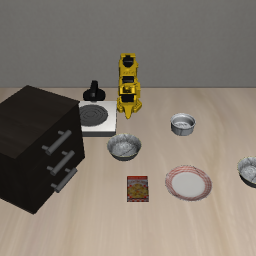

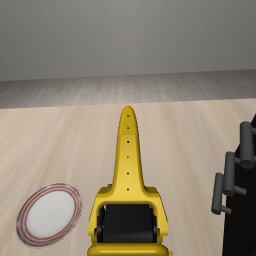

In [18]:
from IPython.display import Image, display
display(Image(f"{OUT_DIR}/soarm_colab_agentview.png"))
display(Image(f"{OUT_DIR}/soarm_colab_eye_in_hand.png"))